# AIoT Project

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values
from utils import subtract_mean

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [5]:
client = pymongo.MongoClient(config["client"])

In [6]:
db = client[config["db"]]
coll = db[config["col"]]

In [7]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 75 keys in the collection


## Load data

In [8]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True, 'user': True}))
print(f'Found {len(results)} keys in the collection')

Found 75 keys in the collection


In [9]:
print(results[0].keys())

dict_keys(['_id', 'data', 'gesture_id', 'user'])


In [10]:
def chop_edges_and_concat(results):
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(500).index, inplace=True)
            df.drop(df.head(500).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
# gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


In [11]:
# print(type(gestures))
# print(len(gestures))
# print(gestures['scroll-down-index']) 

## Explore the nature of the data

We Filter for Glitches/Outliers

In [12]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    # Define your 6 sensor columns from the MetaMotionR IMU
    sensor_columns = axes
    
    for col in sensor_columns:
        # 1. Calculate Rolling Mean and Standard Deviation
        # 'center=True' ensures the window looks at points both before and after the current row
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        global_mean = df_clean[col].mean()
        global_std = df_clean[col].std()
        
        # 2. Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        global_scores = np.abs((df_clean[col] - global_mean) / global_std)
        
        # 3. Find how many outliers we are catching (Great for your EDA Report!)
        outlier_count = (rolling_z_scores > threshold).sum()
        # print(f"Cleaned {outlier_count} glitches in {col}")
        
        # 4. Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        df_clean.loc[global_scores > 2.5, col] = np.nan
        
        # 5. Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        # print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

# cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.5)

# Check the first few rows to ensure everything looks correct
# display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


## Sensor-type grouped scaling

In [13]:

def scale_gestures(gestures_train, gestures_val):
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(cleaned_gestures, [])
    

## We use sliding widnowing to create our samples

In [14]:
# --- REPLACEMENT FOR CELL 18 ---
import scipy.stats as stats
import pandas as pd
import numpy as np

def window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.3, filter_type='lowpass'):
    clips_arr = []
    featurized_gestures = {}
    
    for id, data in cleaned_gestures.items():
        # 1. Slice data into windows
        clips = sliding_window_pd(data.drop(columns=['user'], errors='ignore'), ws=ws, overlap=overlap, print_stats=False)
        
        # 2. Filter the windows
        fclips = filter_instances(clips, order=order, wn=wn, filter_type=filter_type)
        
        total_clips = len(fclips)
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        
        # 3. Feature Extraction 
        extracted_windows = []
        for window in fclips:
            if not isinstance(window, pd.DataFrame):
                window = pd.DataFrame(window, columns=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'])
            
            window_features = {}
            for col in window.columns:
                vals = window[col].values

                # Time-Domain
                window_features[f'{col}_mean'] = np.mean(vals)
                window_features[f'{col}_std'] = np.std(vals)
                window_features[f'{col}_rms'] = np.sqrt(np.mean(vals**2))
                window_features[f'{col}_skew'] = stats.skew(vals)
                window_features[f'{col}_kurtosis'] = stats.kurtosis(vals)
                window_features[f'{col}_iqr'] = stats.iqr(vals)
                zero_crosses = np.where(np.diff(np.sign(vals - np.mean(vals))))[0]
                window_features[f'{col}_zcr'] = len(zero_crosses)
                
                # Frequency-Domain
                fs = 100 
                fft_vals = np.fft.rfft(vals)
                fft_mag = np.abs(fft_vals) / len(vals)
                fft_freqs = np.fft.rfftfreq(len(vals), d=1/fs)

                window_features[f'{col}_spectral_energy'] = np.sum(fft_mag**2)
                
                dom_freq_idx = np.argmax(fft_mag)
                window_features[f'{col}_dom_freq'] = fft_freqs[dom_freq_idx]
                
                sum_mag = np.sum(fft_mag)
                window_features[f'{col}_mean_freq'] = (np.sum(fft_freqs * fft_mag) / sum_mag) if sum_mag > 0 else 0.0
                
                if sum_mag > 0:
                    pmf = fft_mag / sum_mag
                    pmf = pmf[pmf > 0]
                    window_features[f'{col}_spectral_entropy'] = stats.entropy(pmf)
                else:
                    window_features[f'{col}_spectral_entropy'] = 0.0

            # Cross-Channel
            ax, ay, az = window['acc_x'].values, window['acc_y'].values, window['acc_z'].values
            gx, gy, gz = window['gyr_x'].values, window['gyr_y'].values, window['gyr_z'].values
            N = len(ax)
            
            window_features['acc_vm_mean'] = np.mean(np.sqrt(ax**2 + ay**2 + az**2))
            window_features['gyr_vm_mean'] = np.mean(np.sqrt(gx**2 + gy**2 + gz**2))
            window_features['acc_sma'] = np.sum(np.abs(ax) + np.abs(ay) + np.abs(az)) / N
            window_features['gyr_sma'] = np.sum(np.abs(gx) + np.abs(gy) + np.abs(gz)) / N
            
            window_features['acc_corr_xy'] = np.nan_to_num(np.corrcoef(ax, ay)[0, 1])
            window_features['acc_corr_xz'] = np.nan_to_num(np.corrcoef(ax, az)[0, 1])
            window_features['acc_corr_yz'] = np.nan_to_num(np.corrcoef(ay, az)[0, 1])
            window_features['gyr_corr_xy'] = np.nan_to_num(np.corrcoef(gx, gy)[0, 1])
            window_features['gyr_corr_xz'] = np.nan_to_num(np.corrcoef(gx, gz)[0, 1])
            window_features['gyr_corr_yz'] = np.nan_to_num(np.corrcoef(gy, gz)[0, 1])
                
            extracted_windows.append(window_features)
            
        # Store features
        df_features = pd.DataFrame(extracted_windows)
        
        # Clean Inf and NaN before returning
        df_features = df_features.replace([np.inf, -np.inf], np.nan)
        df_features = df_features.fillna(0) # Fill NaNs to prevent downstream errors
        
        featurized_gestures[id] = df_features

    return featurized_gestures, clips_arr

## Main

In [ ]:
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.5)
scale_gestures(cleaned_gestures, {})
featurized_gestures, clip_distr = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.3)
scale_gestures(featurized_gestures)


Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Index(['_id', 'data', 'gesture_id', 'user'], dtype='str')
Number of filtered instances in the list: 1738
Number of filtered instances in the list: 1753
Number of filtered instances in the list: 1734
Number of filtered instances in the list: 1810
Number of filtered instances in the list: 1760


In [16]:
# --- Combine Extracted Features ---
all_features = []
for gesture_id, df_feat in featurized_gestures.items():
    df_feat = df_feat.copy()
    df_feat['gesture_class'] = gesture_id  # Append the target label
    all_features.append(df_feat)

F_matrix = pd.concat(all_features, ignore_index=True)

# Separate X (features) and y (labels)
X = F_matrix.drop(columns=['gesture_class'])
y = F_matrix['gesture_class']

print(f"Full Feature Matrix Shape: {F_matrix.shape}")

Full Feature Matrix Shape: (8795, 77)


In [17]:
# --- ANOVA F-Statistic Ranking ---
from sklearn.feature_selection import f_classif

# Calculate F-statistics
f_stats, p_values = f_classif(X, y)

# Create a ranking dataframe
feature_ranking = pd.DataFrame({
    'Feature': X.columns, 
    'F_Statistic': f_stats, 
    'p_value': p_values
})

# Sort by most discriminative (highest F-score)
feature_ranking = feature_ranking.sort_values(by='F_Statistic', ascending=False)

print("🏆 Top 10 Most Discriminative Features:")
display(feature_ranking.head(10))

# Save the top feature names for our next plots
top_features = feature_ranking['Feature'].head(5).tolist()

🏆 Top 10 Most Discriminative Features:


,Feature,F_Statistic,p_value
22,acc_z_mean,4305.360636,0.0
68,acc_sma,2892.253411,0.0
66,acc_vm_mean,2477.101945,0.0
24,acc_z_rms,2098.237146,0.0
61,gyr_z_zcr,1792.871226,0.0
29,acc_z_spectral_energy,1750.811845,0.0
17,acc_y_zcr,1732.772609,0.0
7,acc_x_spectral_energy,1573.423217,0.0
2,acc_x_rms,1445.487264,0.0
39,gyr_x_zcr,1401.348207,0.0


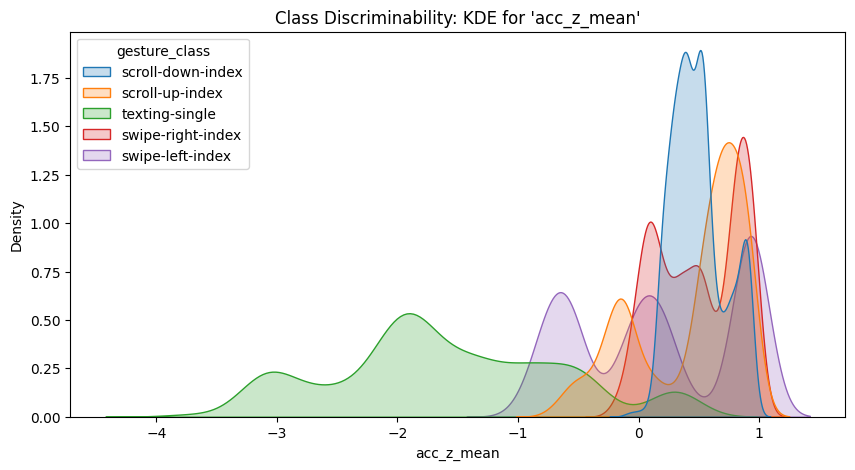

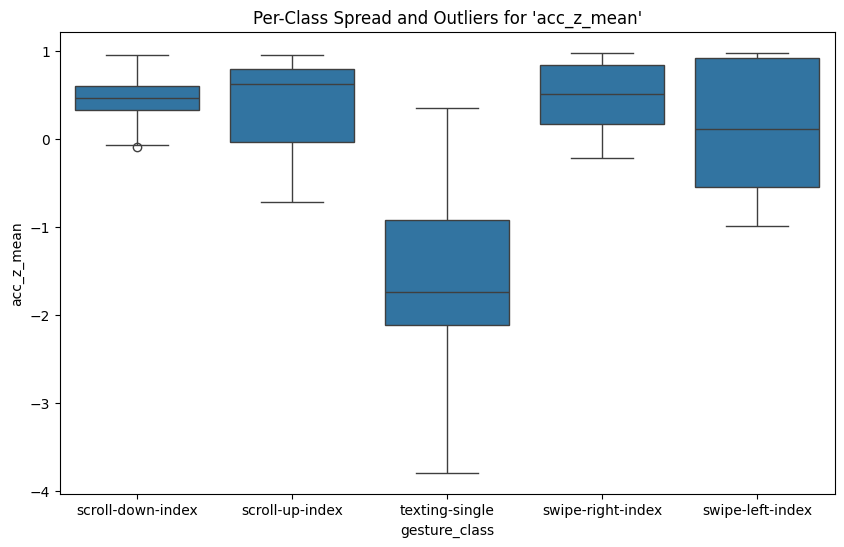

In [18]:
# --- Visualizing Separability ---
from utils_visual import plot_box
import seaborn as sns
import matplotlib.pyplot as plt

# 1. KDE Distribution (Per Class) for the #1 Feature
best_feature = top_features[0]
plt.figure(figsize=(10, 5))
sns.kdeplot(data=F_matrix, x=best_feature, hue='gesture_class', fill=True, common_norm=False)
plt.title(f"Class Discriminability: KDE for '{best_feature}'")
plt.show()

# 2. Boxplot (Spread & Outliers) for the #1 Feature
# (Using Seaborn directly here so we can split by gesture_class)
plt.figure(figsize=(10, 6))
sns.boxplot(data=F_matrix, x='gesture_class', y=best_feature)
plt.title(f"Per-Class Spread and Outliers for '{best_feature}'")
plt.show()

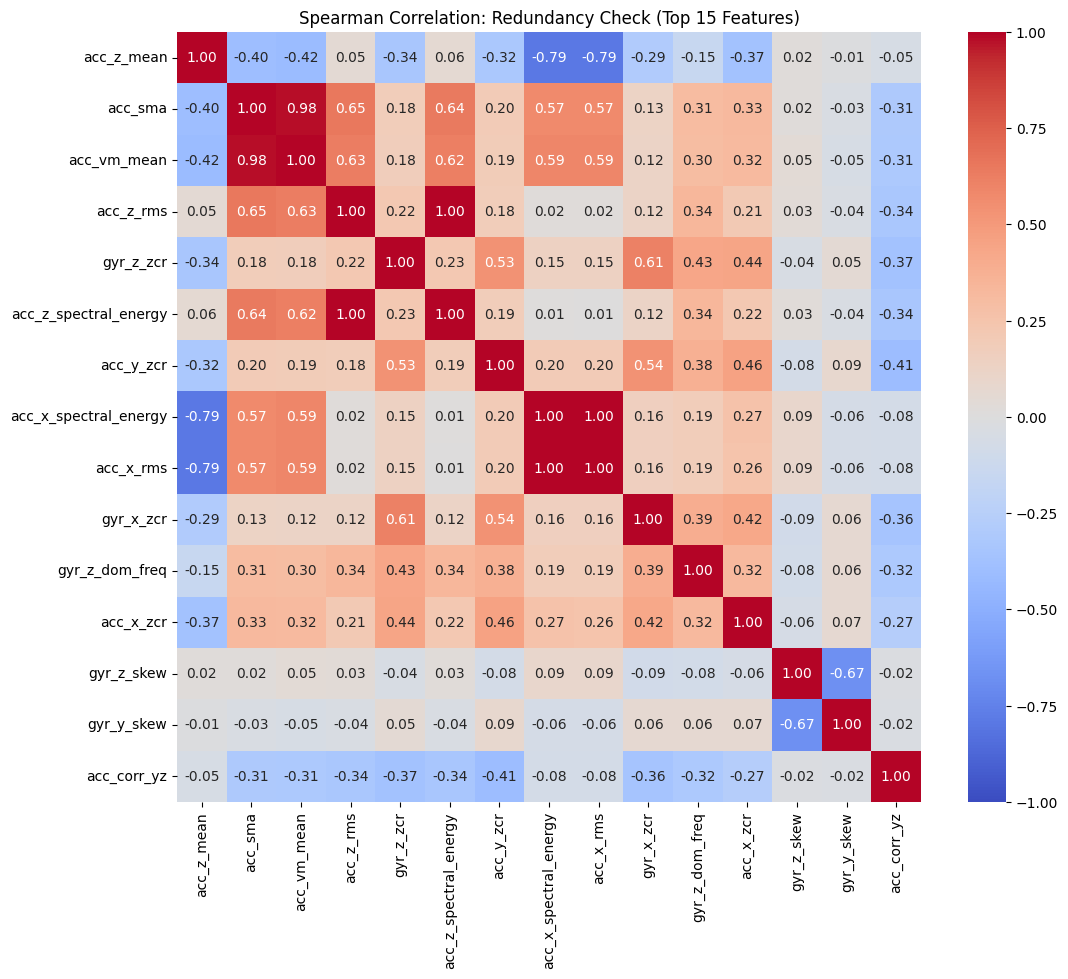

In [21]:
# --- Spearman Correlation Heatmap ---
# Let's check redundancy among our Top 15 features
top_15_features = feature_ranking['Feature'].head(15).tolist()

plt.figure(figsize=(12, 10))
corr_matrix = X[top_15_features].corr(method='spearman')

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Correlation: Redundancy Check (Top 15 Features)")
plt.show()

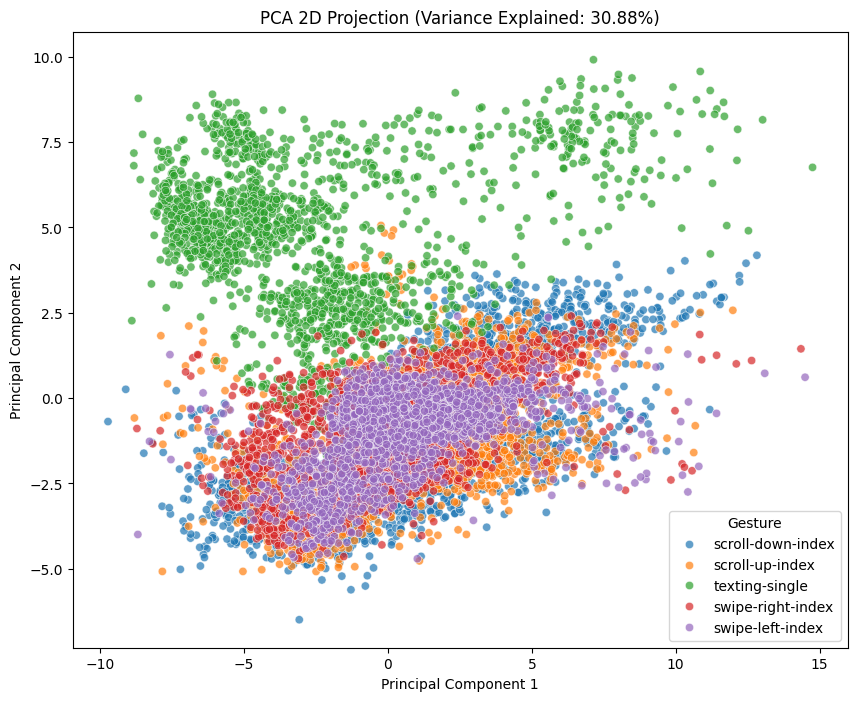

In [28]:
# --- Global Structure Projection (PCA) ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# It is CRITICAL to scale features before PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y, 
    palette='tab10', 
    alpha=0.7
)
plt.title(f"PCA 2D Projection (Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Gesture')
plt.show()

             Gesture  Duration (s)
0  scroll-down-index        870.68
1    scroll-up-index        878.15
2     texting-single        868.92
3  swipe-right-index        906.67
4   swipe-left-index        881.72


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


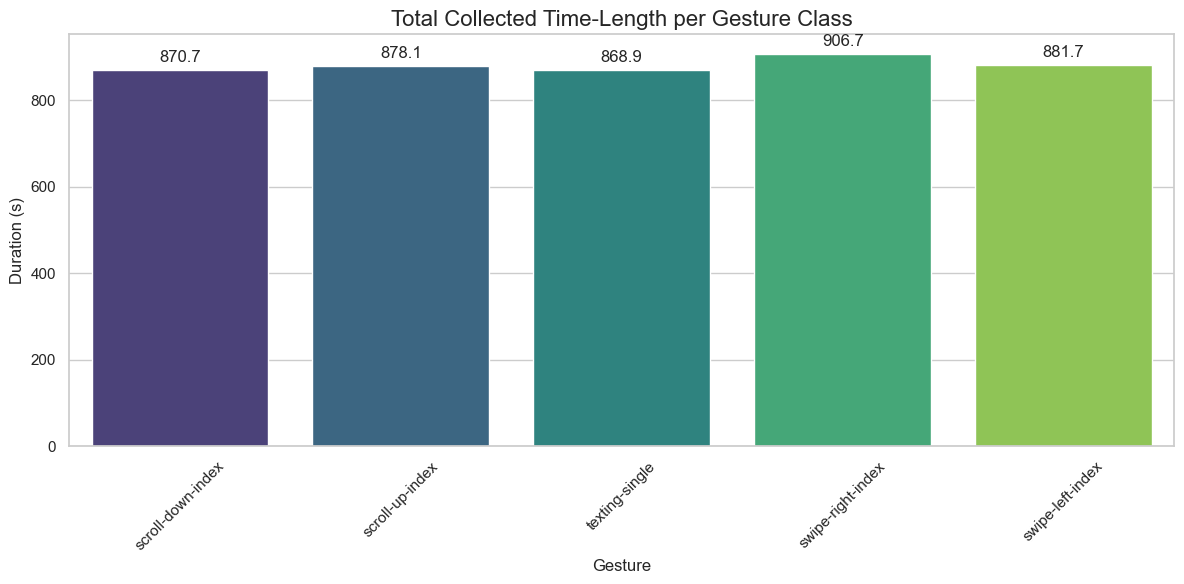

In [21]:
sampling_rate = 100
durations = []
for gesture_id, df in gestures.items():
    total_samples = len(df)
    duration_seconds = total_samples / sampling_rate
    durations.append({'Gesture': gesture_id, 'Duration (s)':
        duration_seconds})

duration_df = pd.DataFrame(durations)
print(duration_df)
   
plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

             Gesture  Windows (#)
0  scroll-down-index         1730
1    scroll-up-index         1745
2     texting-single         1726
3  swipe-right-index         1802
4   swipe-left-index         1752


/Users/koules/Developer/4th_year/IoT-Course-AIoT-project/utils_visual.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=df, x=df.columns[0], y=df.columns[1], palette='viridis')


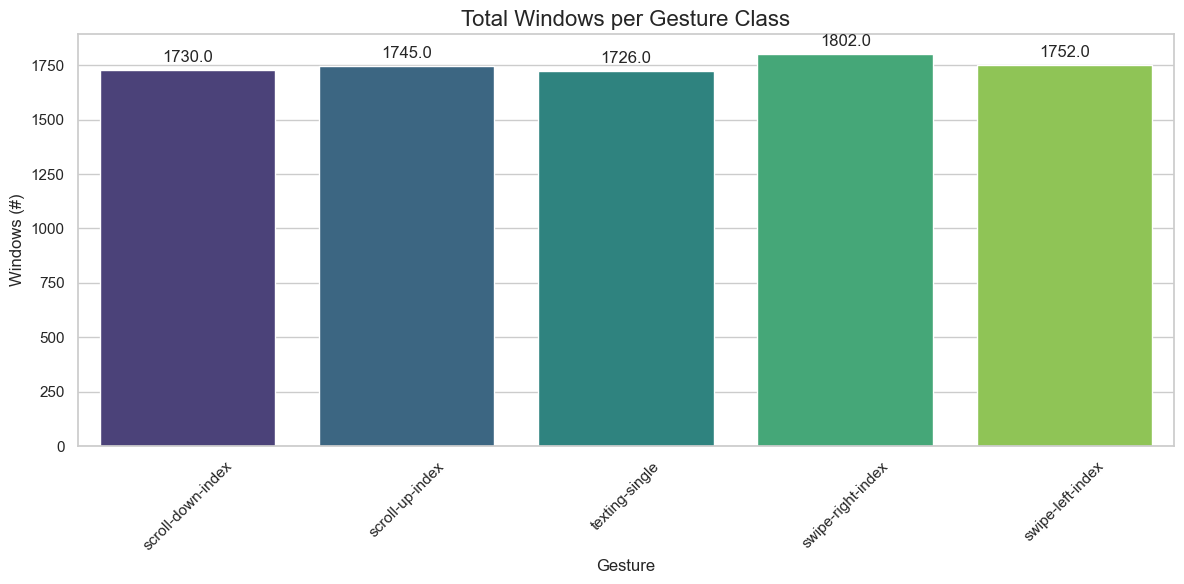

In [22]:
window_counts = []
for gesture_id, df in clipped_gestures.items():
    total_samples = len(df)
    window_counts.append({'Gesture': gesture_id, 'Windows (#)':
        total_samples})

windows_distr_df = pd.DataFrame(window_counts)
print(windows_distr_df)
   
plot_bar(windows_distr_df, title='Total Windows per Gesture Class')